# **<center><h1>SMART BASKET ANALYSIS</h1></center>**

# **Project Summary**

- SmartBasket is a Data Analysis & Visualization (DAV) project designed to analyze pricing dynamics, discount structures, and store value across major Indian e-grocery and quick commerce platforms.
- By combining and cleaning multi-platform retail data, the project provides data-backed insights to help consumers optimize their household grocery spending.
- Through end-to-end data cleaning and structured exploration, the project identifies platform-specific price variations, cross-category discount distributions, and value-for-money trends across 39,000+ grocery listings.

# **Problem Statement**

 Q1. How does the distribution of product sale prices differ across each platform, and what does it reveal about the pricing strategies of different e-commerce platforms?
 
 Q2. Which product categories contribute the highest total sales value based on the total sale price of products? 
 
 Q3. What is the overall distribution of product sale prices, and are most products budget-friendly or premium-priced? 
 
 Q4. Which platform exhibits the greatest variation in product prices, indicating a wider range of budget and premium products? 
 
 Q5. How are customer ratings distributed across different platforms, and which platform demonstrates more consistent customer satisfaction? 
 
 Q6. Is there a significant relationship between the Maximum Retail Price (MRP) and the actual Sale Price of products? 
 
 Q7. Do products with higher discount percentages generally have lower selling prices, or are discounts more common on premium products? 
 
 Q8. Which numerical variables in the dataset are strongly correlated, and what insights can be derived from their relationships?
 
 Q9. How do all numerical variables interact with one another, and what patterns or relationships can be observed among them? 
 
 Q10.What is the relationship between product Sale Price and Customer Rating, and does product price influence customer satisfaction? 
 
 Q11. Which e-commerce platform contributes the largest share of the overall product catalogue?
 
 Q12. Which product categories exhibit the highest variability in sale prices, indicating diverse pricing within the category?
 
 Q13.How are products distributed across different categories and e-commerce platforms, and which platforms dominate specific categories? 
 
 Q14. Which brands provide the best balance between customer ratings and discount percentages, offering greater value to customers? 
 
 Q15. What is the overall density distribution of customer ratings, and are product ratings concentrated around a specific range or widely dispersed?

### Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load the Dataset

In [2]:
df = pd.read_csv('../Data/combined_grocery_dataset.csv',encoding='latin-1')
df

,product_name,platform,category,sub_category,brand,mrp,sale_price,rating,discount_pct
0,Besan 1 kg,JioMart,Staples,"Atta, Flours and Sooji",Besan,160.0,74.0,4.1,53.75
1,Besan 500 g,JioMart,Staples,"Atta, Flours and Sooji",Besan,80.0,37.0,3.8,53.75
2,Maida 1 kg,JioMart,Staples,"Atta, Flours and Sooji",Maida,80.0,32.0,4.2,60.00
3,Rawa 1 kg,JioMart,Staples,"Atta, Flours and Sooji",Rawa,86.0,38.0,4.5,55.81
4,Maida 500 g,JioMart,Staples,"Atta, Flours and Sooji",Maida,40.0,17.5,3.8,56.25
...,...,...,...,...,...,...,...,...,...
39421,ï»¿Raag Gold Palmolein Oil,Blinkit,Out of Stock,NaN,ï»¿raag,108.0,92.0,3.5,14.81
39422,ï»¿Samyang Ramen Instant Noodles - Kimchi,Blinkit,Out of Stock,NaN,ï»¿samyang,NaN,120.0,4.2,0.00
39423,ï»¿Slurrp Farm Millet Healthy Instant Noodles,Blinkit,General Grocery,NaN,ï»¿slurrp,NaN,140.0,4.6,0.00
39424,ï»¿The Body Shop Strawberry Body Butter,Blinkit,General Grocery,NaN,ï»¿the,NaN,1395.0,4.1,0.00


### Observations

- there are total 39426 entries
- in this dataset there are 9 columns

### Understanding the Dataset Columns

| Column Name | Type | Purpose |
| :--- | :--- | :--- |
| **`product_name`** | Text | Identifies the specific item, brand, and packaging variant. |
| **`platform`** | Text | Specifies the e-grocery store or app fulfilling the product. |
| **`category`** | Text | Groups items into high-level departments. |
| **`sub_category`** | Text | Classifies items into specific sub-types. |
| **`brand`** | Text | Names the product manufacturer or store house brand. |
| **`mrp`** | Numeric (₹) | Records the official Maximum Retail Price of the product. |
| **`sale_price`** | Numeric (₹) | Captures the final discounted selling price offered on the platform. |
| **`discount_pct`** | Numeric (%) | Measures the exact markdown percentage ($\frac{\text{MRP} - \text{Sale Price}}{\text{MRP}} \times 100$). |
| **`rating`** | Numeric (1-5) | Reflects average customer satisfaction and product quality scores. |

## **Data Exploration**

### Inspecting the first 5 rows gives us an initial glimpse of the dataset structure.

In [3]:
df.head()

,product_name,platform,category,sub_category,brand,mrp,sale_price,rating,discount_pct
0,Besan 1 kg,JioMart,Staples,"Atta, Flours and Sooji",Besan,160.0,74.0,4.1,53.75
1,Besan 500 g,JioMart,Staples,"Atta, Flours and Sooji",Besan,80.0,37.0,3.8,53.75
2,Maida 1 kg,JioMart,Staples,"Atta, Flours and Sooji",Maida,80.0,32.0,4.2,60.00
3,Rawa 1 kg,JioMart,Staples,"Atta, Flours and Sooji",Rawa,86.0,38.0,4.5,55.81
4,Maida 500 g,JioMart,Staples,"Atta, Flours and Sooji",Maida,40.0,17.5,3.8,56.25


### Checking the last 5 rows reveals potential data hygiene issues.

In [4]:
df.tail()

,product_name,platform,category,sub_category,brand,mrp,sale_price,rating,discount_pct
39421,ï»¿Raag Gold Palmolein Oil,Blinkit,Out of Stock,NaN,ï»¿raag,108.0,92.0,3.5,14.81
39422,ï»¿Samyang Ramen Instant Noodles - Kimchi,Blinkit,Out of Stock,NaN,ï»¿samyang,NaN,120.0,4.2,0.00
39423,ï»¿Slurrp Farm Millet Healthy Instant Noodles,Blinkit,General Grocery,NaN,ï»¿slurrp,NaN,140.0,4.6,0.00
39424,ï»¿The Body Shop Strawberry Body Butter,Blinkit,General Grocery,NaN,ï»¿the,NaN,1395.0,4.1,0.00
39425,ï»¿Yu Zingy Cheese Instant Cup Noodles (80 g),Blinkit,General Grocery,NaN,ï»¿yu,69.0,49.0,4.5,28.99


### We verify the scale of our raw dataset, confirming a total of 39,426 rows and 9 feature columns.

In [5]:
df.shape

(39426, 9)

### Checking the data types and non-null counts.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39426 entries, 0 to 39425
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  39425 non-null  str    
 1   platform      39426 non-null  str    
 2   category      39426 non-null  str    
 3   sub_category  33227 non-null  str    
 4   brand         39426 non-null  str    
 5   mrp           39117 non-null  float64
 6   sale_price    39425 non-null  float64
 7   rating        39426 non-null  float64
 8   discount_pct  39426 non-null  float64
dtypes: float64(4), str(5)
memory usage: 5.8 MB


### Generating comprehensive summary statistics.

In [7]:
df.describe(include='all')

,product_name,platform,category,sub_category,brand,mrp,sale_price,rating,discount_pct
count,39425,39426,39426,33227,39426,39117.000000,39425.000000,39426.000000,39426.000000
unique,33288,4,29,120,3183,NaN,NaN,NaN,NaN
top,Turmeric Powder/Arisina Pudi,BigBasket,Beauty & Hygiene,Skin Care,Fresho,NaN,NaN,NaN,NaN
freq,26,27555,7867,2294,638,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,350.249472,290.368628,4.021648,12.452878
std,NaN,NaN,NaN,NaN,NaN,632.840217,503.232647,0.574839,14.301789
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,90.000000,80.000000,3.800000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,195.000000,165.000000,4.100000,7.550000
75%,NaN,NaN,NaN,NaN,NaN,377.000000,315.000000,4.300000,20.000000


### We list all column names to confirm our dataset's feature set before beginning deeper exploration.

In [8]:
df.columns

Index(['product_name', 'platform', 'category', 'sub_category', 'brand', 'mrp',
       'sale_price', 'rating', 'discount_pct'],
      dtype='str')

### We check the numerical and object data types across columns to ensure numeric fields are ready for mathematical operations.

In [9]:
df.dtypes

product_name        str
platform            str
category            str
sub_category        str
brand               str
mrp             float64
sale_price      float64
rating          float64
discount_pct    float64
dtype: object

### We audit missing values across all columns.

In [10]:
df.isnull().sum()

product_name       1
platform           0
category           0
sub_category    6199
brand              0
mrp              309
sale_price         1
rating             0
discount_pct       0
dtype: int64

### We check for exact duplicate rows in the dataset.

In [11]:
df.duplicated().sum()

np.int64(214)

### We print unique values for each column to inspect string formatting, identify hidden special characters, and discover uncleaned category values.

In [12]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print()

Column: product_name
<ArrowStringArray>
[                                                     'Besan 1 kg',
                                                     'Besan 500 g',
                                                      'Maida 1 kg',
                                                       'Rawa 1 kg',
                                                     'Maida 500 g',
                                                      'Rawa 500 g',
                            'Good Life MP Wheat Chakki Atta 10 kg',
                                     'Uttam Superfine Maida 500 g',
                                'Aashirvaad Whole Wheat Atta 5 kg',
                                      'Rajdhani Chana Sattu 500 g',
 ...
 'ï»¿Nissin Geki Hot & Spicy Korean Veg Flavoured Instant Noodles',
                'ï»¿Nissin Spiced Chicken Cup Noodles - Pack of 2',
                          'ï»¿Pandit Vishnu Sharma'S Panchatantra',
                                                      'ï»¿Pawsome',
   

### We count the number of distinct values per column.

In [13]:
df.nunique()

product_name    33288
platform            4
category           29
sub_category      120
brand            3183
mrp              1590
sale_price       4606
rating             40
discount_pct     3517
dtype: int64

In [14]:
max_mrp = df.loc[df['mrp'].idxmax(), ['product_name', 'platform', 'mrp']]
print("Maximum MRP")
print(max_mrp)

min_mrp = df.loc[df['mrp'].idxmin(), ['product_name', 'platform', 'mrp']]
print("\nMinimum MRP")
print(min_mrp)

Maximum MRP
product_name    Dyson Cool Gen1 Air Purifier (50 W)
platform                                    Blinkit
mrp                                         39900.0
Name: 37598, dtype: object

Minimum MRP
product_name    Cherry Blossom Liquid Shoe Polish Neutral 
platform                                             Zepto
mrp                                                    0.0
Name: 36833, dtype: object


#### Observation: finding the highest-priced item at ₹39,900 (Dyson Air Purifier) and an invalid minimum MRP of ₹0.0.

In [15]:
max_sale = df.loc[df['sale_price'].idxmax(), ['product_name', 'platform', 'sale_price']]
print("Maximum Sale Price")
print(max_sale)

min_sale = df.loc[df['sale_price'].idxmin(), ['product_name', 'platform', 'sale_price']]
print("\nMinimum Sale Price")
print(min_sale)

Maximum Sale Price
product_name    Dyson Cool Gen1 Air Purifier (50 W)
platform                                    Blinkit
sale_price                                  32899.0
Name: 37598, dtype: object

Minimum Sale Price
product_name    Cherry Blossom Liquid Shoe Polish Neutral 
platform                                             Zepto
sale_price                                             0.0
Name: 36833, dtype: object


#### Observation: We evaluate the selling price extremes to spot potential zero-price scraping errors alongside high-end product listings.

In [16]:
max_discount = df.loc[df['discount_pct'].idxmax(), ['product_name', 'platform', 'discount_pct']]
print("Maximum Discount")
print(max_discount)

min_discount = df.loc[df['discount_pct'].idxmin(), ['product_name', 'platform', 'discount_pct']]
print("\nMinimum Discount")
print(min_discount)

Maximum Discount
product_name    Curry Leaves
platform           BigBasket
discount_pct           83.67
Name: 32648, dtype: object

Minimum Discount
product_name    Patanjali Kachi Ghani Mustard Oil 1 L (Bottle)
platform                                               JioMart
discount_pct                                               0.0
Name: 584, dtype: object


#### Observation: We locate the maximum discount offered in the dataset (83.67% on Curry Leaves) and identify non-discounted baseline items (0% discount).

In [17]:
avg_rating = df.groupby('platform', as_index=False)['rating'].mean()
print(avg_rating)

    platform    rating
0  BigBasket  3.992332
1    Blinkit  4.199392
2    JioMart  3.901217
3      Zepto  4.303644


#### Observation: We aggregate average customer ratings by platform to establish baseline quality comparison scores across BigBasket, Blinkit, JioMart, and Zepto.

## **Data Cleaning**

### We will strip unwanted encoding artifacts (`ï»¿`) and extra quotation marks from product titles and brand names.

In [18]:
df['product_name']=df['product_name'].str.replace({'ï»¿':'','"':''})
df['brand']=df['brand'].str.replace({'ï»¿':'','"':''})

### We isolate corrupted category values containing leftover quotation mark strings (`"`).

In [19]:
df.loc[df['category'].str.contains('"')]

,product_name,platform,category,sub_category,brand,mrp,sale_price,rating,discount_pct
3686,Dove Nutritive Solutions Hair Fall Rescue Sham...,JioMart,"""",Hair care,Dove,620.0,370.0,4.9,40.32


### We replace corrupt category text with the correct department label (`Personal Care`).

In [20]:
df['category']=df['category'].str.replace('"','Personal Care')
print(df.loc[3686,'category'])

Personal Care


In [21]:
df["brand"] = (
    df["brand"]
    .str.encode("latin1", errors="ignore")
    .str.decode("utf-8", errors="ignore")
)
df["brand"] = df["brand"].str.title()

### We drop the 214 exact duplicate rows from our dataset to prevent distorted aggregation results.

In [22]:
df = df.drop_duplicates()

### We build a domain-specific mapping dictionary to fill all 6,199 missing `sub_category` entries based on parent category definitions.

In [23]:
category_to_sub = {
    'Fruits & Vegetables': 'Fresh Produce',
    'General Grocery': 'Daily Essentials',
    'Home & Cleaning': 'Household Care',
    'Beverages': 'Drinks & Juices',
    'Beauty & Hygiene': 'Personal Care',
    'Foodgrains, Oil & Masala': 'Staples',
    'Snacks & Branded Foods': 'Snacks & Packaged Food',
    'Kitchen, Garden & Pets': 'Home & Kitchen'
}

df['sub_category'] = df['sub_category'].fillna(df['category'].map(category_to_sub))

df['sub_category'] = df['sub_category'].fillna(df['category'])

print("Remaining missing values in sub_category:", df['sub_category'].isnull().sum())

Remaining missing values in sub_category: 0


### We filter out invalid records where both MRP and selling price are ₹0.00.

In [24]:
df = df[~(df['mrp'].fillna(0).eq(0) & df['sale_price'].fillna(0).eq(0))].copy()

### We mathematically reconstruct missing MRP values using existing selling prices and discount percentages.

In [25]:
df['mrp'] = np.where(
    df['mrp'].isnull() | (df['mrp'] == 0),
    np.where(
        df['discount_pct'] > 0,
        np.round(df['sale_price'] / (1 - df['discount_pct'] / 100), 2),
        df['sale_price']
    ),
    df['mrp']
)

In [26]:
print("Remaining missing MRPs:", df['mrp'].isnull().sum())
print("Remaining zero MRPs   :", (df['mrp'] == 0).sum())

Remaining missing MRPs: 0
Remaining zero MRPs   : 0


### We locate the single row missing a product name (row index 20035).

In [27]:
df.loc[df['product_name'].isnull(), 'product_name']

20035    NaN
Name: product_name, dtype: str

### We inspect all attributes of row 20035, identifying it as Cothas Coffee priced at ₹200.

In [28]:
df.loc[20035]

product_name              NaN
platform            BigBasket
category            Beverages
sub_category           Coffee
brand           Cothas Coffee
mrp                     240.0
sale_price              200.0
rating                    4.2
discount_pct            16.67
Name: 20035, dtype: object

### We populate the missing product name with `'Cothas Coffee Powder 500g'` based on brand and pricing match.

In [29]:
df.loc[df['product_name'].isnull(), 'product_name'] = 'Cothas Coffee Powder 500g'

In [30]:
df.loc[20035]

product_name    Cothas Coffee Powder 500g
platform                        BigBasket
category                        Beverages
sub_category                       Coffee
brand                       Cothas Coffee
mrp                                 240.0
sale_price                          200.0
rating                                4.2
discount_pct                        16.67
Name: 20035, dtype: object

### We locate the single row missing a selling price (row index 39400).

In [31]:
df.loc[df['sale_price'].isnull(), 'sale_price']

39400   NaN
Name: sale_price, dtype: float64

### We inspect row 39400, confirming a Philips Hair Straightener with an MRP of ₹3,399 and a 0% discount.

In [32]:
df.loc[39400]

product_name    Philips 50 Watts Hair Straightener (With Kerat...
platform                                                  Blinkit
category                                          General Grocery
sub_category                                     Daily Essentials
brand                                                     Philips
mrp                                                        3399.0
sale_price                                                    NaN
rating                                                        4.1
discount_pct                                                  0.0
Name: 39400, dtype: object

 ### We fill the missing `sale_price` using the `mrp` value since the item has a 0% discount.

In [33]:
df['sale_price'] = df['sale_price'].fillna(df['mrp'])

In [34]:
df.loc[39400]

product_name    Philips 50 Watts Hair Straightener (With Kerat...
platform                                                  Blinkit
category                                          General Grocery
sub_category                                     Daily Essentials
brand                                                     Philips
mrp                                                        3399.0
sale_price                                                 3399.0
rating                                                        4.1
discount_pct                                                  0.0
Name: 39400, dtype: object

### We perform a final missing value audit to confirm that our entire dataset is now 100% clean and fully prepared for exploratory visualization and analysis.

In [35]:
df.isnull().sum()

product_name    0
platform        0
category        0
sub_category    0
brand           0
mrp             0
sale_price      0
rating          0
discount_pct    0
dtype: int64

### Outlier Detection

In [36]:
columns = [
    'mrp',
    'sale_price',
    'discount_pct'
]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

mrp: 3116 outliers
sale_price: 3236 outliers
discount_pct: 615 outliers


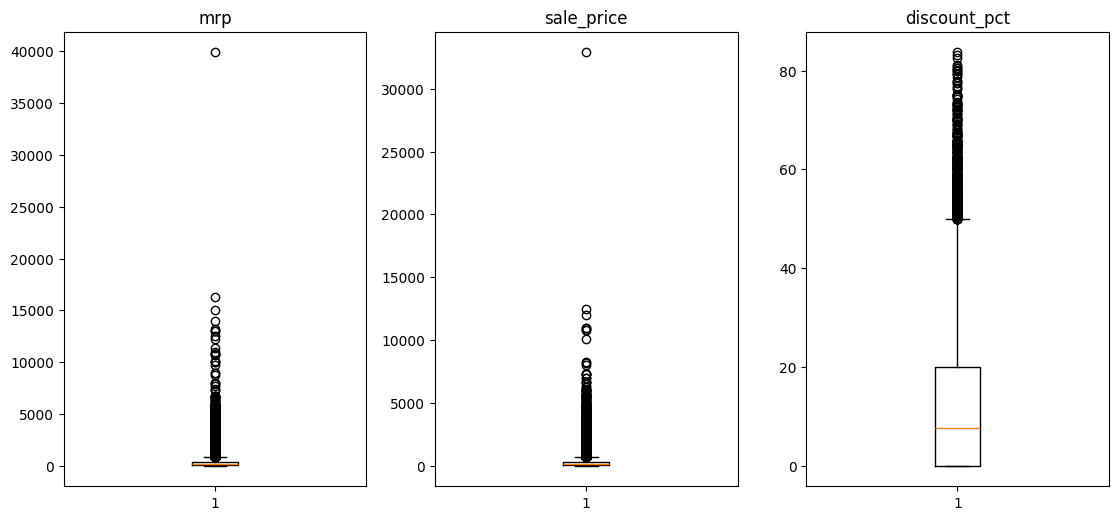

In [37]:
plt.figure(figsize=(15,10))

for i, col in enumerate(columns, 1):
    plt.subplot(2,4,i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Observation: Outliers were detected using the IQR method. However, they were not removed because most represented premium products such as dyson etc. which is genuine.

### Now our datset is cleaned so we will store it in a new modified dataset

In [38]:
df.to_csv("modified_dataset.csv", index=False)

## **Exploratory Data Analysis and Questions**

### Now we will import our modified dataset

In [39]:
df=pd.read_csv('../Data/modified_dataset.csv')
df.head(5)

,product_name,platform,category,sub_category,brand,mrp,sale_price,rating,discount_pct
0,Besan 1 kg,JioMart,Staples,"Atta, Flours and Sooji",Besan,160.0,74.0,4.1,53.75
1,Besan 500 g,JioMart,Staples,"Atta, Flours and Sooji",Besan,80.0,37.0,3.8,53.75
2,Maida 1 kg,JioMart,Staples,"Atta, Flours and Sooji",Maida,80.0,32.0,4.2,60.00
3,Rawa 1 kg,JioMart,Staples,"Atta, Flours and Sooji",Rawa,86.0,38.0,4.5,55.81
4,Maida 500 g,JioMart,Staples,"Atta, Flours and Sooji",Maida,40.0,17.5,3.8,56.25


### Question 1: How does the distribution of product sale prices differ across each platform?

In [40]:
df.groupby("platform")["sale_price"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
BigBasket,27342.0,322.12,487.01,2.45,95.00,190.0,356.25,12500.0
Blinkit,2466.0,424.40,1004.10,11.98,99.44,199.0,397.48,32899.0
JioMart,5672.0,173.95,348.41,4.65,52.00,99.0,193.46,10799.0
Zepto,3730.0,141.97,138.52,9.00,55.00,104.0,184.00,1399.0


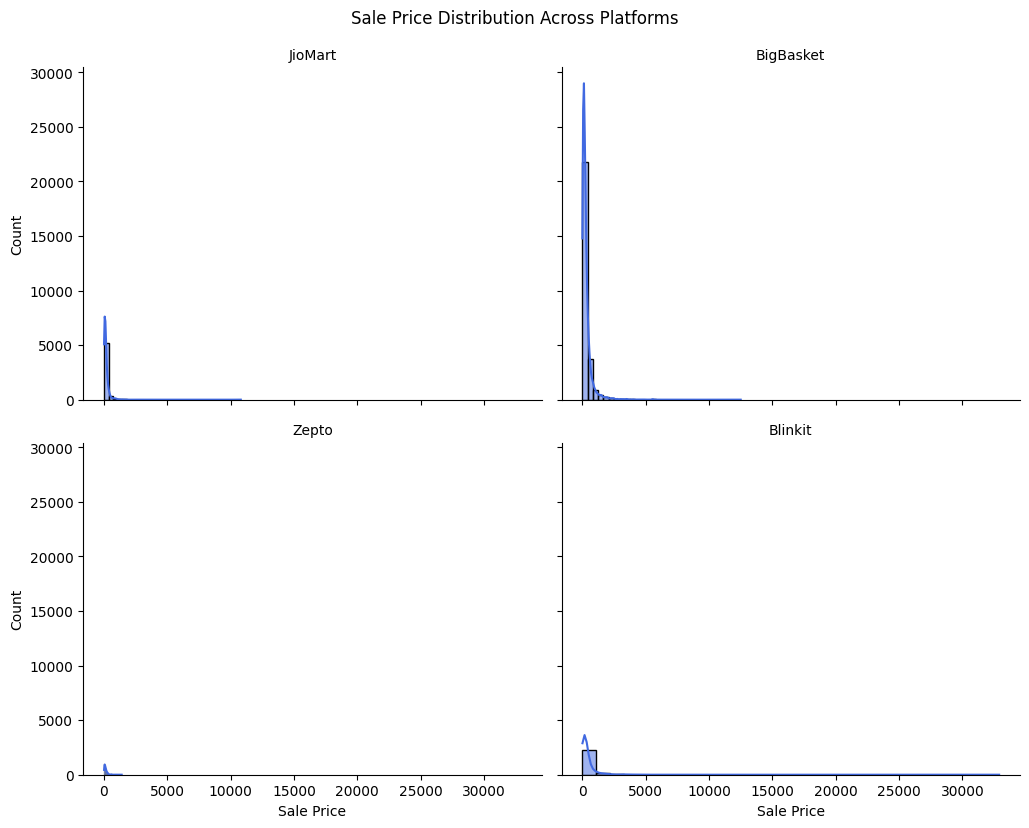

In [42]:
g = sns.FacetGrid(
    df,
    col="platform",
    col_wrap=2,
    height=4,
    aspect=1.3
)

g.map_dataframe(
    sns.histplot,
    x="sale_price",
    bins=30,
    kde=True,
    color="royalblue"
)

g.set_axis_labels("Sale Price", "Count")
g.set_titles("{col_name}")

plt.suptitle("Sale Price Distribution Across Platforms", y=1.03)
plt.savefig(
    "../images/FacetGrid.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Observation
- BigBasket contains products across the widest price range.
- Blinkit and Zepto mainly contain low to medium-priced products.
- JioMart products are concentrated in the lower price range.

### Question 2: Which product categories contribute the highest total sales value?

In [48]:
category_sales = (
    df.groupby("category")["sale_price"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

category
Beauty & Hygiene            3249558.90
Kitchen, Garden & Pets      1787796.12
Gourmet & World Food        1498871.81
Cleaning & Household         601410.09
General Grocery              599247.76
Foodgrains, Oil & Masala     516641.23
Out of Stock                 447330.94
Staples                      408801.38
Personal care                367011.21
Snacks & Branded Foods       364290.08
Baby Care                    326317.17
Beverages                    297300.35
Snacks and branded foods     138171.07
Bakery, Cakes & Dairy        121525.14
Eggs, Meat & Fish            101114.12
Munchies                      72385.00
Cooking Essentials            72385.00
Personal Care                 65640.00
Paan Corner                   65135.00
Chocolates & Candies          54738.00
Packaged Food                 54738.00
Ice Cream & Desserts          54738.00
Fruits & Vegetables           32050.36
Home & Cleaning               27441.00
Health & Hygiene              14148.00
Dairy, Bread & B

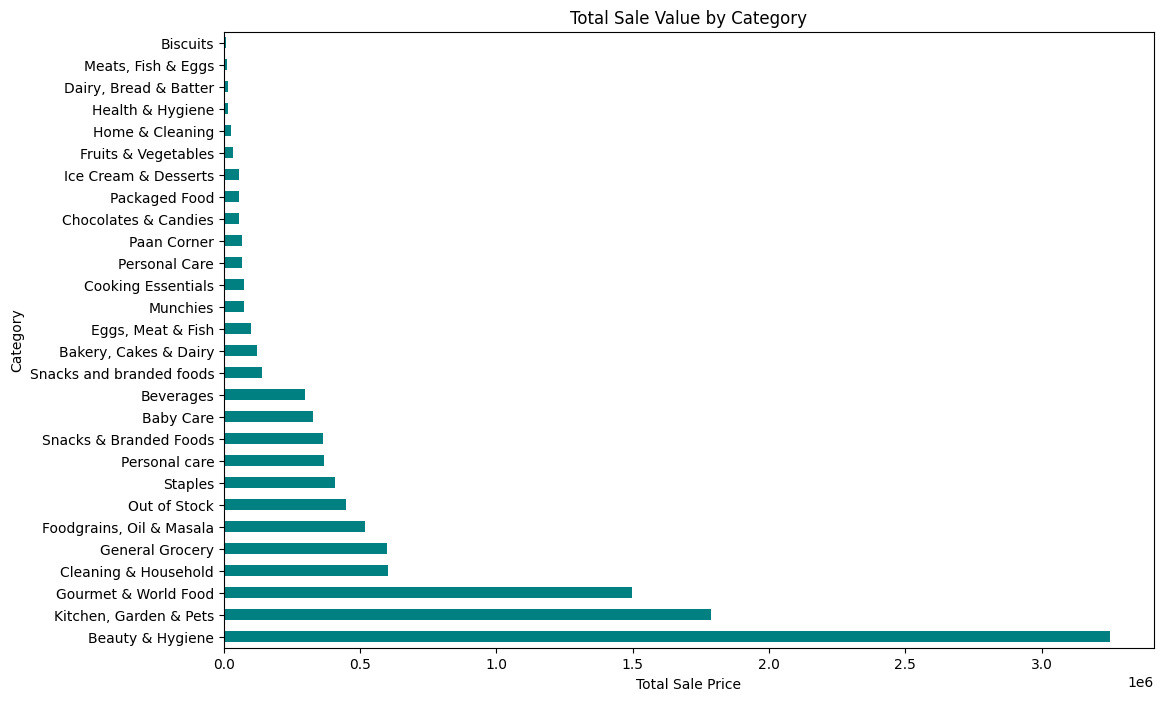

In [49]:
plt.figure(figsize=(12,8))

category_sales.plot(
    kind="barh",
    color="teal"
)

plt.title("Total Sale Value by Category")
plt.xlabel("Total Sale Price")
plt.ylabel("Category")

plt.show()

#### Observation
- Beauty & Hygiene contributes the highest sales value followed by Kitchen, Garden & Pets.

### Question 3: What is the overall distribution of product sale prices? Are most products budget or premium?

In [50]:
print(df["sale_price"].describe())
print(df["sale_price"].skew())

count    39210.000000
mean       289.983763
std        504.027119
min          2.450000
25%         80.000000
50%        164.000000
75%        315.000000
max      32899.000000
Name: sale_price, dtype: float64
13.227208172292249


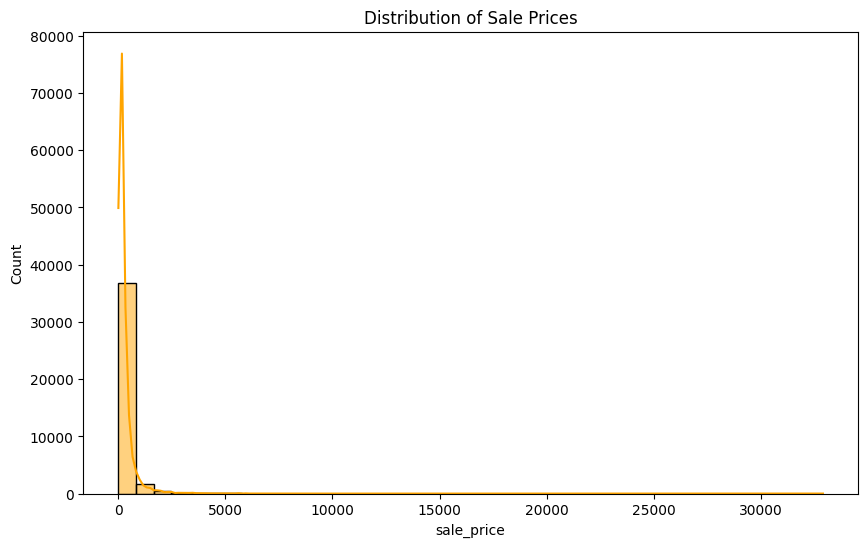

In [51]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="sale_price",
    bins=40,
    kde=True,
    color="orange"
)

plt.title("Distribution of Sale Prices")
plt.savefig(
    "../images/histogram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Observation
- Most products are priced in the lower range.
- Very expensive products are comparatively few.
- Distribution is positively skewed.

### Question 4: Which platform has the widest variation in product prices?

In [52]:
df.groupby("platform")["sale_price"].agg(
    ["min","max","mean","std"]
).round(2)

,min,max,mean,std
platform,,,,
BigBasket,2.45,12500.0,322.12,487.01
Blinkit,11.98,32899.0,424.40,1004.10
JioMart,4.65,10799.0,173.95,348.41
Zepto,9.00,1399.0,141.97,138.52


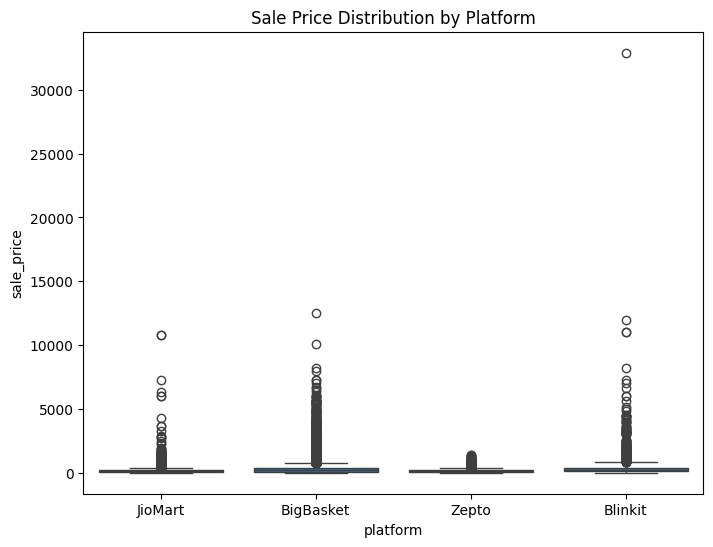

In [53]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="platform",
    y="sale_price"
)

plt.title("Sale Price Distribution by Platform")

plt.show()

#### Observation
- BigBasket shows the widest spread.
- Blinkit has comparatively less variation.
- Numerous outliers indicate premium products.

### Question 5: How are customer ratings distributed across different platforms?

In [54]:
platform_rating = (
    df.groupby("platform")["rating"]
      .mean()
      .sort_values(ascending=False)
)

print(platform_rating)

platform
Zepto        4.303619
Blinkit      4.199432
BigBasket    3.993252
JioMart      3.901217
Name: rating, dtype: float64


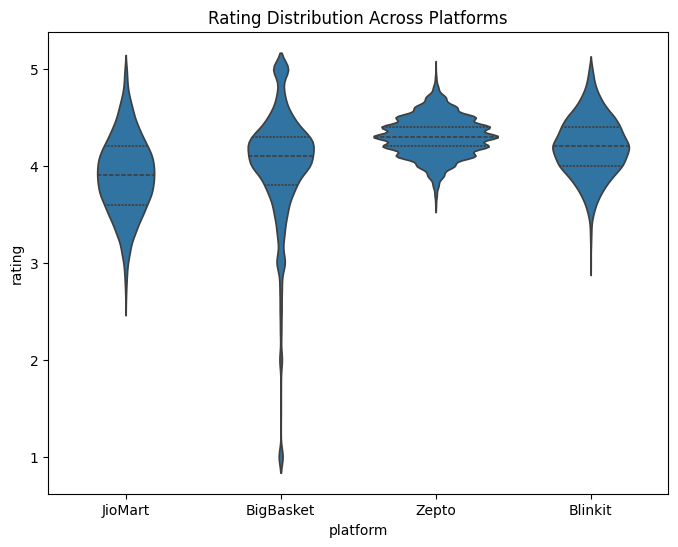

In [55]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x="platform",
    y="rating",
    inner="quartile"
)

plt.title("Rating Distribution Across Platforms")

plt.show()

#### Observation
- Ratings are concentrated around 4–4.5 across all platforms.
- Some platforms have more consistent ratings than others.

### Question 6: Is there a relationship between MRP and Sale Price?

In [56]:
correlation = df["mrp"].corr(df["sale_price"])
print(f"Correlation: {correlation:.3f}")

Correlation: 0.960


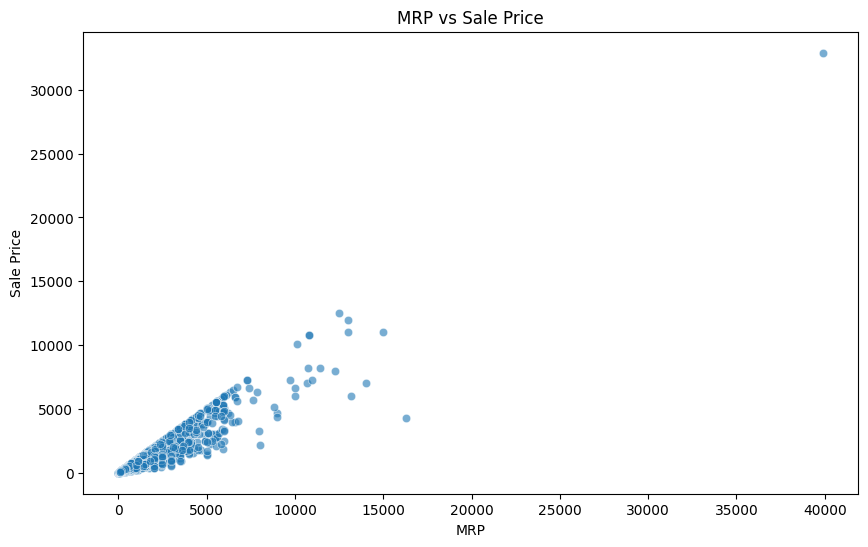

In [57]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="mrp",
    y="sale_price",
    alpha=0.6
)

plt.title("MRP vs Sale Price")
plt.xlabel("MRP")
plt.ylabel("Sale Price")
plt.savefig(
    "../images/scatterplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Observation
- A strong positive relationship exists between MRP and Sale Price.
- Higher MRP products generally have higher selling prices.

### Question 7: Do products with higher discounts generally sell at lower prices?

In [58]:
print(df[["discount_pct", "sale_price"]].corr())

              discount_pct  sale_price
discount_pct      1.000000    0.035958
sale_price        0.035958    1.000000


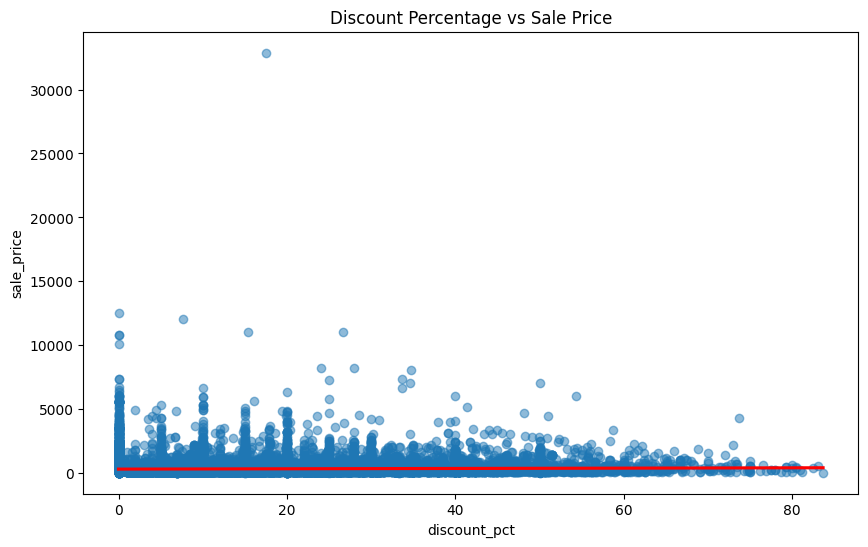

In [59]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="discount_pct",
    y="sale_price",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Discount Percentage vs Sale Price")

plt.show()

#### Observation:
- Products with higher discounts are not always the cheapest.
- Premium products often receive larger percentage discounts.

### Question 8: Which numerical variables are strongly correlated?

In [46]:
corr = df[["mrp","sale_price","rating","discount_pct"]].corr()

print(corr)

                   mrp  sale_price    rating  discount_pct
mrp           1.000000    0.959602 -0.034368      0.176946
sale_price    0.959602    1.000000 -0.028893      0.035958
rating       -0.034368   -0.028893  1.000000     -0.047480
discount_pct  0.176946    0.035958 -0.047480      1.000000


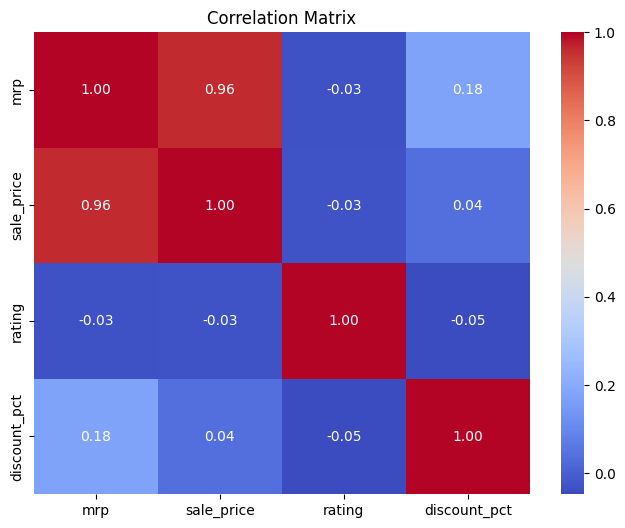

In [47]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.savefig(
    "../images/heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Observation:
- MRP and Sale Price have a very high positive correlation.
- Discount Percentage is negatively correlated with Sale Price.

### Question 9: How do all numerical variables interact with one another?

In [60]:
numeric_df = df[["mrp","sale_price","rating","discount_pct"]]

numeric_df.describe()

,mrp,sale_price,rating,discount_pct
count,39210.000000,39210.000000,39210.000000,39210.000000
mean,349.583802,289.983763,4.022431,12.463019
std,633.293973,504.027119,0.571759,14.307361
min,3.000000,2.450000,1.000000,0.000000
25%,90.000000,80.000000,3.800000,0.000000
50%,195.000000,164.000000,4.100000,7.570000
75%,375.000000,315.000000,4.300000,20.000000
max,39900.000000,32899.000000,5.000000,83.670000


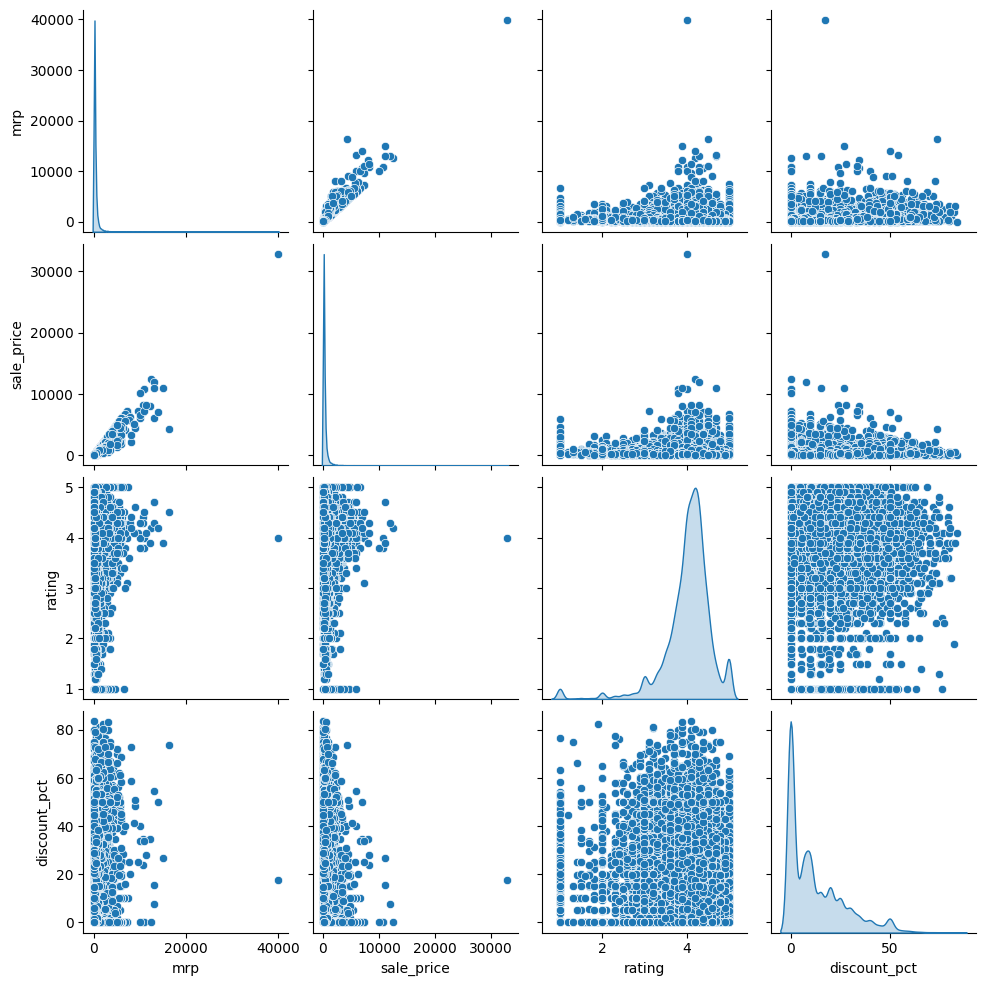

In [61]:
sns.pairplot(
    numeric_df,
    diag_kind="kde"
)
plt.savefig(
    "../images/pairplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Observation
- MRP and Sale Price exhibit a clear positive relationship.
- Discount percentage shows greater variability.

### Question 10: What is the joint relationship between Sale Price and Rating?

In [62]:
print(df[["sale_price","rating"]].corr())

            sale_price    rating
sale_price    1.000000 -0.028893
rating       -0.028893  1.000000


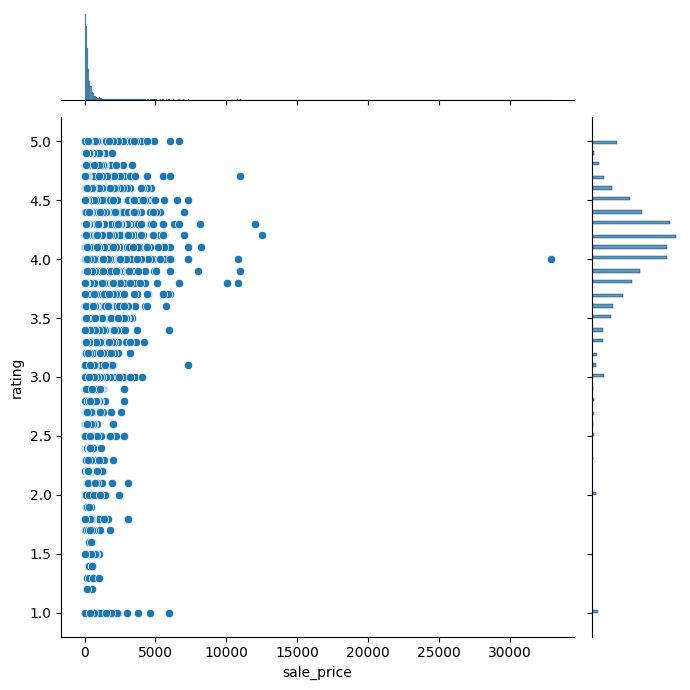

In [63]:
sns.jointplot(
    data=df,
    x="sale_price",
    y="rating",
    kind="scatter",
    height=7
)

plt.show()

#### Observation
- Ratings remain consistently high across different price ranges.
- Premium products do not necessarily receive better ratings.

### Question 11: Which platforms contribute the largest share of the overall product catalogue?

In [64]:
platform_count = df["platform"].value_counts()

print(platform_count)

platform
BigBasket    27342
JioMart       5672
Zepto         3730
Blinkit       2466
Name: count, dtype: int64


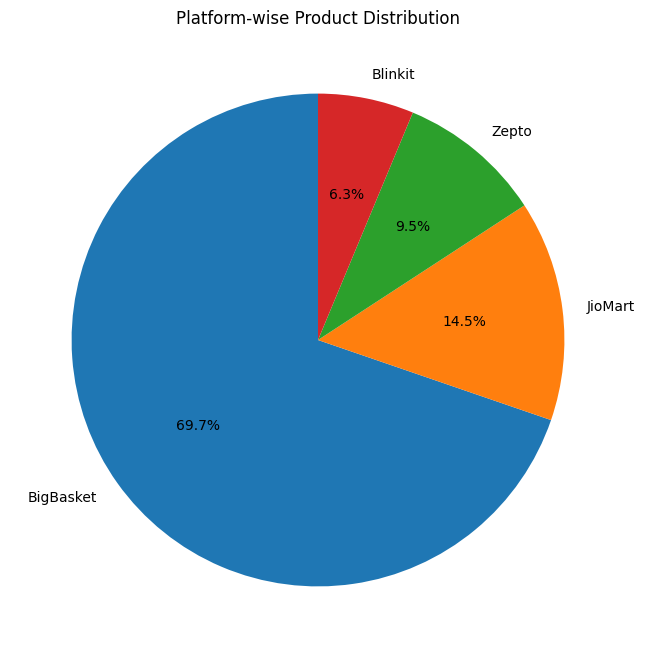

In [65]:
plt.figure(figsize=(8,8))

plt.pie(
    platform_count,
    labels=platform_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Platform-wise Product Distribution")

plt.show()

#### Observation
- One platform contributes the highest percentage of products.
- The remaining platforms share the rest of the catalogue.

### Question 12: Which categories have the highest variation in product prices?

In [66]:
df.groupby("category")["sale_price"].agg(
    ["min","max","mean","std"]
).round(2)

,min,max,mean,std
category,,,,
Baby Care,15.00,3299.00,534.95,536.03
"Bakery, Cakes & Dairy",5.00,1108.00,142.80,131.12
Beauty & Hygiene,3.00,8184.44,419.46,593.16
Beverages,4.65,3480.00,205.32,229.28
Biscuits,10.00,350.00,52.78,41.65
Chocolates & Candies,10.00,650.00,141.08,119.31
Cleaning & Household,5.00,3600.00,226.26,251.52
Cooking Essentials,10.00,1399.00,140.83,172.17
"Dairy, Bread & Batter",15.00,372.00,103.73,68.24


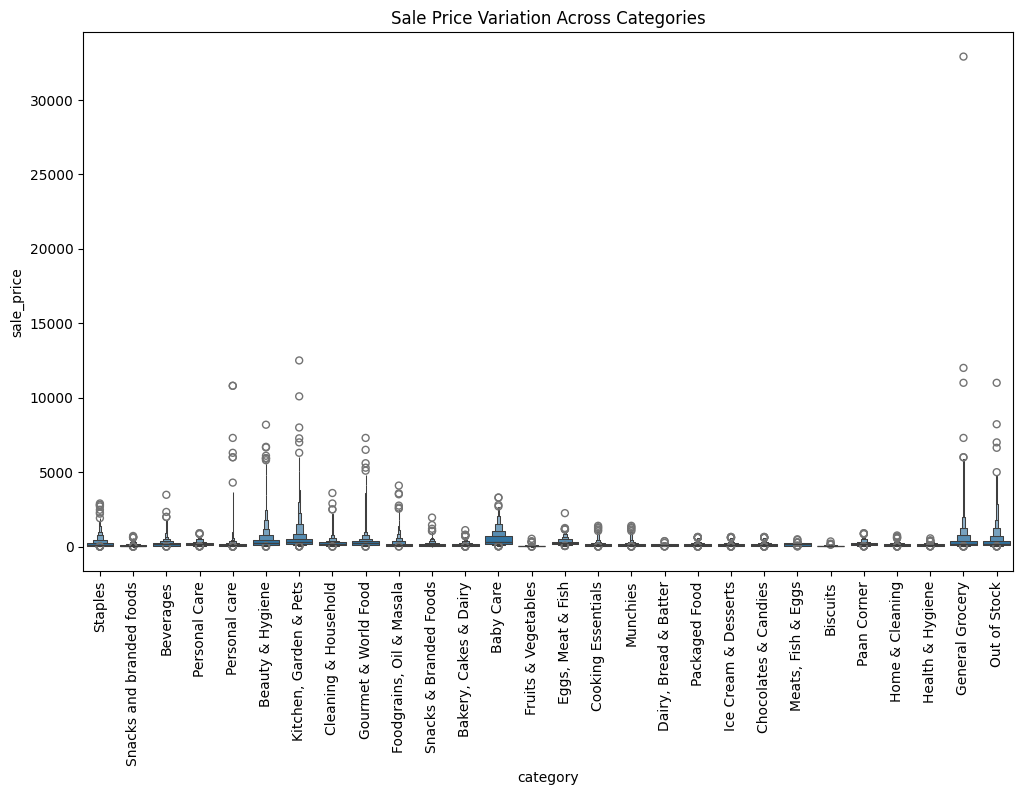

In [68]:
plt.figure(figsize=(12,7))

sns.boxenplot(
    data=df,
    x="category",
    y="sale_price"
)

plt.xticks(rotation=90)

plt.title("Sale Price Variation Across Categories")
plt.savefig(
    "../images/boxenplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation
- Some categories have a very wide price range.
- Others contain products within a narrow price range.

### Question 13: How are products distributed across categories and platforms?

In [69]:
cross = pd.crosstab(
    df["category"],
    df["platform"]
)

print(cross)

platform                  BigBasket  Blinkit  JioMart  Zepto
category                                                    
Baby Care                       610        0        0      0
Bakery, Cakes & Dairy           851        0        0      0
Beauty & Hygiene               7747        0        0      0
Beverages                       884        0      435    129
Biscuits                          0        0        0    147
Chocolates & Candies              0        0        0    388
Cleaning & Household           2658        0        0      0
Cooking Essentials                0        0        0    514
Dairy, Bread & Batter             0        0        0    129
Eggs, Meat & Fish               350        0        0      0
Foodgrains, Oil & Masala       2673        0        0      0
Fruits & Vegetables             557        0        0     93
General Grocery                   0     1366        0      0
Gourmet & World Food           4682        0        0      0
Health & Hygiene        

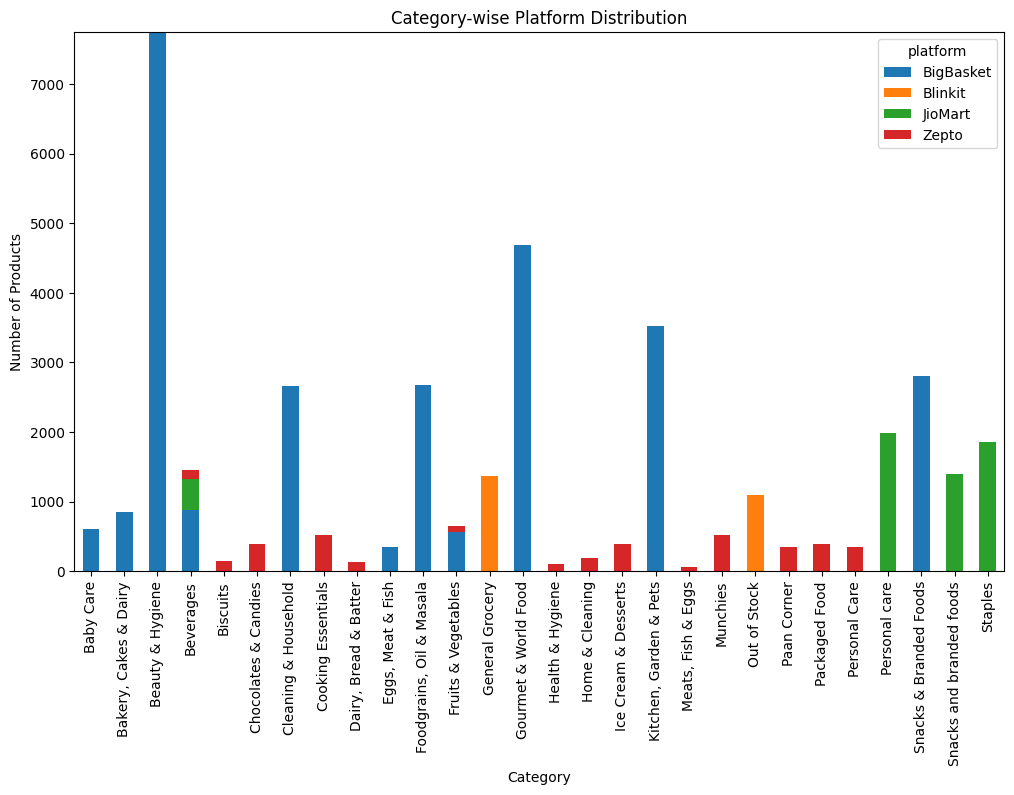

In [70]:
cross.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.title("Category-wise Platform Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=90)
plt.savefig(
    "../images/stackedbar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Observation
- Certain categories are dominated by a single platform.
- Other categories are evenly distributed across multiple platforms.

### Question 14: Which brands provide the best balance between customer ratings and discounts?

In [71]:
brand_summary = (
    df.groupby("brand")
      .agg(
          avg_rating=("rating", "mean"),
          avg_discount=("discount_pct", "mean"),
          products=("brand", "count")
      )
      .reset_index()
)

# Keep brands with at least 10 products
brand_summary = brand_summary[brand_summary["products"] >= 10]

# Sort by highest rating and discount
brand_summary = brand_summary.sort_values(
    ["avg_rating", "avg_discount"],
    ascending=[False, False]
)

brand_summary.head(10)

,brand,avg_rating,avg_discount,products
1411,Kaadoo,4.569231,24.756154,13
2946,Vahdam,4.464407,15.762712,59
1833,Morpheme Remedies,4.452632,1.561053,19
2281,Purecult,4.450000,30.000000,12
2819,The Whole Truth,4.450000,15.000000,14
2129,Papergrid,4.430000,5.027000,10
1244,Hi-Luxe,4.412500,11.623125,16
2831,Tide,4.400000,6.724167,12
1153,Greenberry Organics,4.392857,19.285714,14
363,Bobs Red Mill,4.392857,2.857143,14


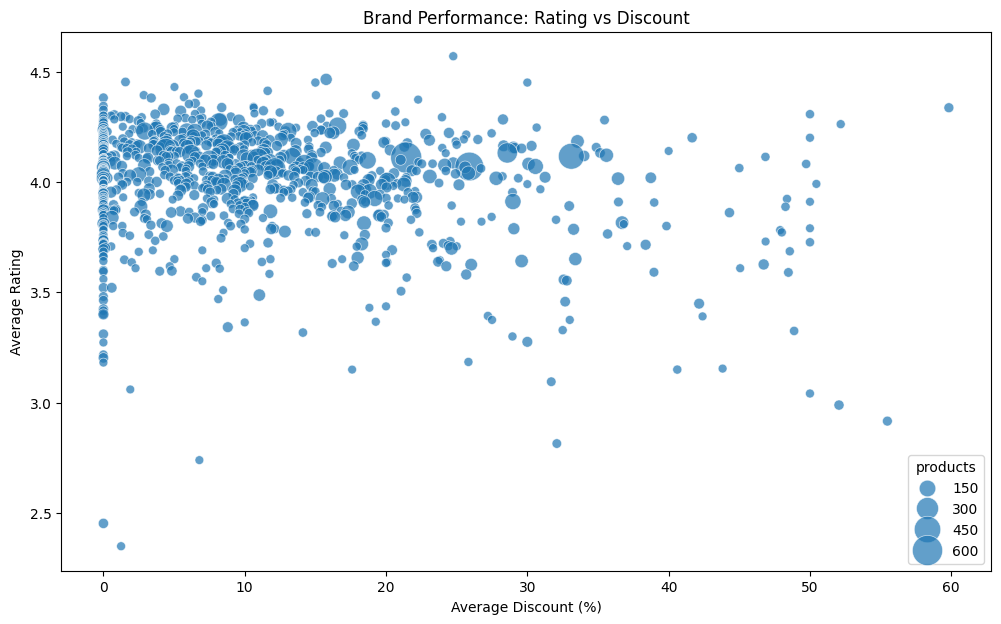

In [72]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=brand_summary,
    x="avg_discount",
    y="avg_rating",
    size="products",
    sizes=(40,500),
    alpha=0.7
)

plt.title("Brand Performance: Rating vs Discount")
plt.xlabel("Average Discount (%)")
plt.ylabel("Average Rating")

plt.show()

#### Observation
- Some brands achieve high ratings while offering attractive discounts.
- Larger bubbles indicate brands with a higher number of products.

### Question 15: How are customer ratings distributed overall? Is the distribution skewed or approximately normal?

In [73]:
print(df["rating"].describe())
print("Skewness:", df["rating"].skew())

count    39210.000000
mean         4.022431
std          0.571759
min          1.000000
25%          3.800000
50%          4.100000
75%          4.300000
max          5.000000
Name: rating, dtype: float64
Skewness: -2.069942895249147


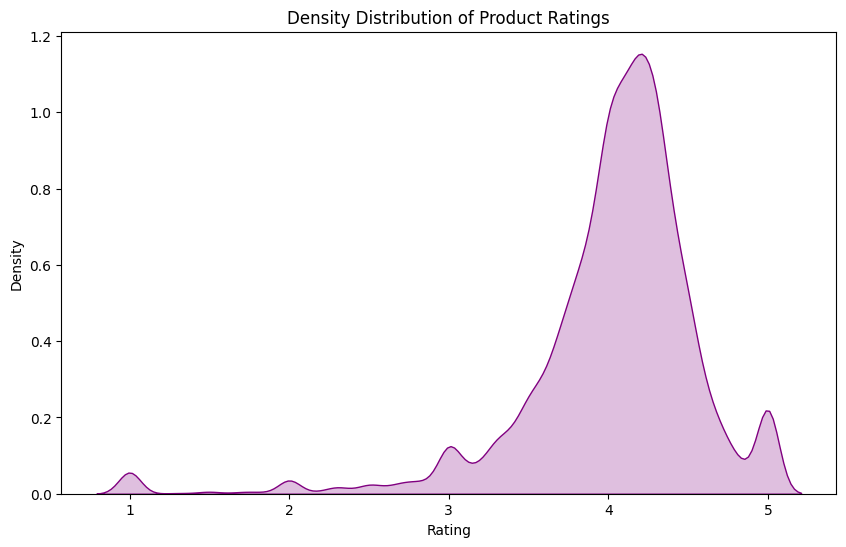

In [74]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x="rating",
    fill=True,
    color="purple"
)

plt.title("Density Distribution of Product Ratings")
plt.xlabel("Rating")

plt.show()

#### Observation
- Most ratings are concentrated between 4.0 and 5.0.
- Very few products have poor ratings.

## **Business Conclusion**

- The EDA highlights that sales are concentrated in a few high-performing categories, with strong pricing consistency between MRP and sale price across all platforms.
-  Most products receive positive customer ratings, suggesting good customer satisfaction.
-  These insights can help businesses optimize inventory, design effective pricing and discount strategies, and focus marketing efforts on the most profitable product categories.